# Week 7-8: Regression and Classification

**Regression:** Linear, Polynomial, Ridge / Lasso  
**Classification:** Logistic Regression, KNN

Name: Your Name | Roll No: ______

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import r2_score, mean_squared_error, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

np.random.seed(7)   # same data every time we run

## Part 1: Regression

Regression predicts a **number**. Here we predict exam marks from hours studied.
The data is made up: marks = 30 + 11x - 0.6x² + random noise, so the real trend is a curve.

In [2]:
n = 60
hours = np.sort(np.random.uniform(1, 10, n))
marks = 30 + 11 * hours - 0.6 * hours ** 2 + np.random.normal(0, 5, n)

X = hours.reshape(-1, 1)
y = marks

# keep 25% of the data aside for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=1)
print("Training rows:", len(X_train), "| Test rows:", len(X_test))

Training rows: 45 | Test rows: 15


In [3]:
# helper functions used for all the regression models
grid = np.linspace(1, 10, 200).reshape(-1, 1)

def evaluate(model, name):
    model.fit(X_train, y_train)
    return {"Model": name,
            "Train R2": round(r2_score(y_train, model.predict(X_train)), 3),
            "Test R2": round(r2_score(y_test, model.predict(X_test)), 3),
            "Test MSE": round(mean_squared_error(y_test, model.predict(X_test)), 1)}

def plot_model(model, title, ax):
    ax.scatter(X_train, y_train, label="Train", color="royalblue")
    ax.scatter(X_test, y_test, label="Test", facecolors="none", edgecolors="crimson", s=70, linewidths=2)
    ax.plot(grid, model.predict(grid), color="green", label="Model")
    ax.set_ylim(0, 110); ax.set_title(title)
    ax.set_xlabel("Hours studied"); ax.set_ylabel("Marks"); ax.legend()

### 1. Linear Regression
Fits a straight line `y = b + w·x`.

{'Model': 'Linear', 'Train R2': 0.773, 'Test R2': 0.783, 'Test MSE': 31.4}


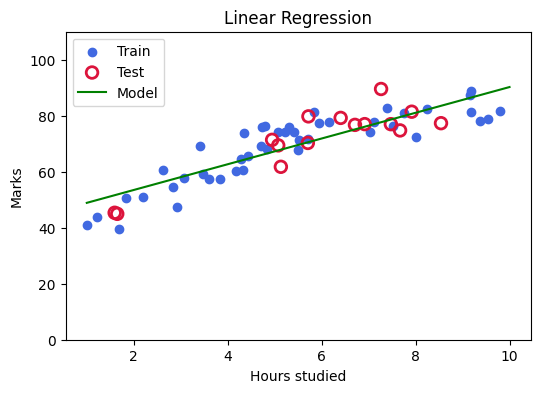

In [4]:
linear = LinearRegression()
print(evaluate(linear, "Linear"))
fig, ax = plt.subplots(figsize=(6, 4))
plot_model(linear, "Linear Regression", ax)
plt.show()

### 2. Polynomial Regression
Adds x², x³ ... as new features so the line can curve.
A very high degree fits the training points too closely (**overfitting**): train score is high but test score drops.

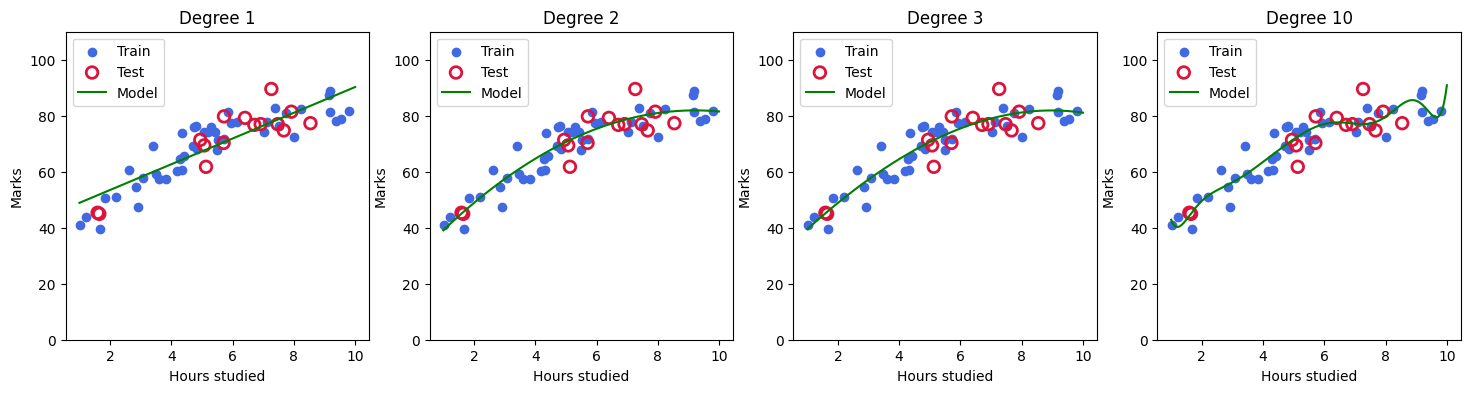

,Model,Train R2,Test R2,Test MSE
0,Polynomial degree 1,0.773,0.783,31.4
1,Polynomial degree 2,0.869,0.857,20.8
2,Polynomial degree 3,0.869,0.856,20.8
3,Polynomial degree 10,0.884,0.819,26.3


In [5]:
degrees = [1, 2, 3, 10]
results = []
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for d, ax in zip(degrees, axes):
    model = make_pipeline(PolynomialFeatures(d, include_bias=False), StandardScaler(), LinearRegression())
    results.append(evaluate(model, f"Polynomial degree {d}"))
    plot_model(model, f"Degree {d}", ax)
plt.show()
pd.DataFrame(results)

**Observation:** degree 2 or 3 matches the real curve. Degree 10 wiggles through every training point, so its test R² is worse.

### 3. Ridge and Lasso Regression
Both are polynomial regression (degree 8) with a **penalty** (`alpha`) on large weights.

- **Ridge (L2)** shrinks all the weights.
- **Lasso (L1)** can push some weights to exactly 0 (a kind of feature selection).

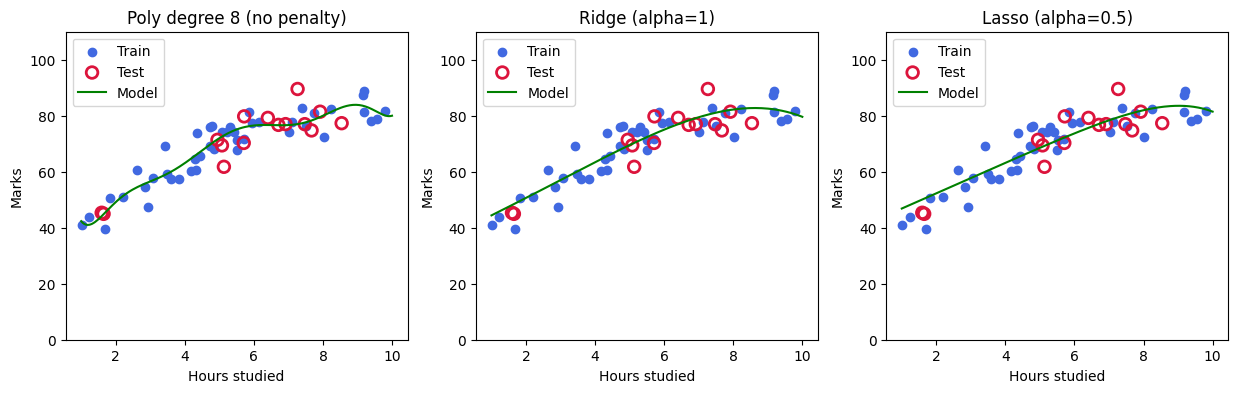

,Model,Train R2,Test R2,Test MSE
0,Poly degree 8 (no penalty),0.883,0.818,26.3
1,Ridge (alpha=1),0.856,0.846,22.3
2,Lasso (alpha=0.5),0.834,0.827,25.1


In [6]:
def poly_model(reg):
    return make_pipeline(PolynomialFeatures(8, include_bias=False), StandardScaler(), reg)

models = {
    "Poly degree 8 (no penalty)": poly_model(LinearRegression()),
    "Ridge (alpha=1)": poly_model(Ridge(alpha=1.0)),
    "Lasso (alpha=0.5)": poly_model(Lasso(alpha=0.5, max_iter=100000)),
}
results = []
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for (name, model), ax in zip(models.items(), axes):
    results.append(evaluate(model, name))
    plot_model(model, name, ax)
plt.show()
pd.DataFrame(results)

In [7]:
# compare the weights: Ridge makes them smaller, Lasso makes some exactly 0
coefs = pd.DataFrame({name: m[-1].coef_ for name, m in models.items()},
                     index=[f"x^{i}" for i in range(1, 9)]).round(2)
coefs

,Poly degree 8 (no penalty),Ridge (alpha=1),Lasso (alpha=0.5)
x^1,-841.83,13.90,12.86
x^2,9666.25,3.68,0.00
x^3,-48593.88,-1.28,-0.00
x^4,135081.07,-2.84,-0.00
x^5,-220174.16,-2.64,-0.00
x^6,209079.37,-1.64,-0.00
x^7,-107006.26,-0.39,-3.18
x^8,22798.85,0.84,-0.00


In [8]:
# what happens when alpha (the penalty) changes?
rows = []
for a in [0.01, 0.1, 0.5, 1, 3]:
    r = evaluate(poly_model(Ridge(alpha=a)), f"Ridge alpha={a}")
    l = evaluate(poly_model(Lasso(alpha=a, max_iter=100000)), f"Lasso alpha={a}")
    rows += [r, l]
pd.DataFrame(rows)

,Model,Train R2,Test R2,Test MSE
0,Ridge alpha=0.01,0.871,0.858,20.5
1,Lasso alpha=0.01,0.871,0.858,20.6
2,Ridge alpha=0.1,0.870,0.859,20.4
3,Lasso alpha=0.1,0.863,0.852,21.5
4,Ridge alpha=0.5,0.864,0.854,21.2
5,Lasso alpha=0.5,0.834,0.827,25.1
6,Ridge alpha=1,0.856,0.846,22.3
7,Lasso alpha=1,0.788,0.780,31.8
8,Ridge alpha=3,0.833,0.826,25.2
9,Lasso alpha=3,0.714,0.675,47.1


**Observation (in our run):** with no penalty the degree-8 weights are huge (tens of thousands) and the test R² is 0.818.
A moderate penalty (Ridge alpha=1) shrinks the weights to small numbers and raises the test R² to 0.846. Lasso sets most weights to exactly 0.
If alpha is too big (Lasso alpha=3) the model becomes too simple (underfitting) and the test R² falls to 0.675.

## Part 2: Classification

Classification predicts a **category**. Here we predict Pass (1) or Fail (0) from hours studied and attendance %.

In [9]:
m = 100
passed = np.random.randint(0, 2, m)
hours_c = np.clip(np.where(passed == 1, 7, 3) + np.random.normal(0, 1.6, m), 0, 10)
attend = np.clip(np.where(passed == 1, 80, 55) + np.random.normal(0, 11, m), 30, 100)

data = pd.DataFrame({"hours": hours_c, "attendance": attend, "passed": passed})
Xc = data[["hours", "attendance"]].values
yc = data["passed"].values
Xc_train, Xc_test, yc_train, yc_test = train_test_split(Xc, yc, test_size=0.25, stratify=yc, random_state=1)
data.head()

,hours,attendance,passed
0,4.927902,72.754031,1
1,5.988370,86.561373,1
2,0.237298,44.459565,0
3,6.395773,79.378575,1
4,4.312243,62.502865,0


In [10]:
def plot_boundary(model, title, ax):
    # colour the background by what the model predicts at every point
    xx, yy = np.meshgrid(np.linspace(0, 10, 200), np.linspace(30, 100, 200))
    zz = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, zz, alpha=0.25, cmap="RdYlGn", levels=[-0.5, 0.5, 1.5])
    ax.scatter(Xc_train[:, 0], Xc_train[:, 1], c=yc_train, cmap="RdYlGn", edgecolors="k")
    ax.scatter(Xc_test[:, 0], Xc_test[:, 1], c=yc_test, cmap="RdYlGn", edgecolors="k", marker="s", s=70)
    ax.set_title(title); ax.set_xlabel("Hours studied"); ax.set_ylabel("Attendance %")

### 4. Logistic Regression
Uses the sigmoid function to turn a score into the probability of passing. The decision boundary is always a straight line.
Features are standardised first so hours and attendance count equally. (Circles = train, squares = test.)

Train accuracy: 0.96
Test accuracy : 0.96


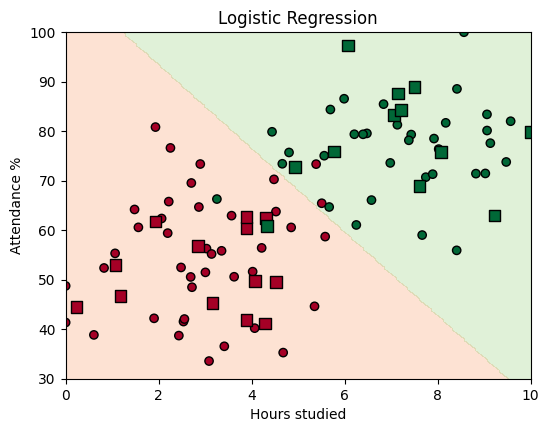

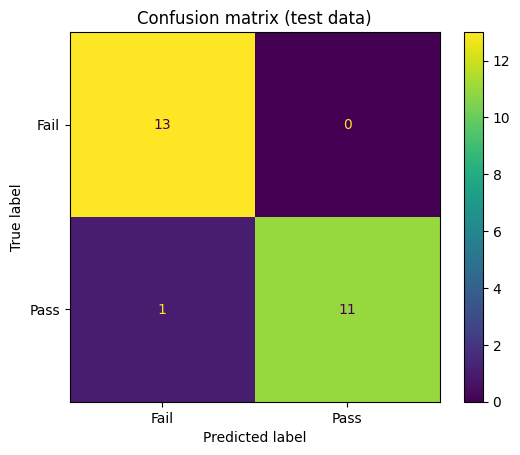

In [11]:
logreg = make_pipeline(StandardScaler(), LogisticRegression())
logreg.fit(Xc_train, yc_train)
print("Train accuracy:", round(logreg.score(Xc_train, yc_train), 3))
print("Test accuracy :", round(logreg.score(Xc_test, yc_test), 3))

fig, ax = plt.subplots(figsize=(6, 4.5))
plot_boundary(logreg, "Logistic Regression", ax)
plt.show()

ConfusionMatrixDisplay(confusion_matrix(yc_test, logreg.predict(Xc_test)), display_labels=["Fail", "Pass"]).plot()
plt.title("Confusion matrix (test data)")
plt.show()

### 5. KNN (K-Nearest Neighbours)
For a new student, look at the **k closest** students and take a majority vote.
Small k follows every point (jagged boundary, overfitting). Large k is smoother.

In [12]:
rows = []
for k in [1, 3, 5, 7, 9, 11, 15]:
    knn = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=k)).fit(Xc_train, yc_train)
    rows.append({"k": k, "Train accuracy": round(knn.score(Xc_train, yc_train), 3),
                 "Test accuracy": round(knn.score(Xc_test, yc_test), 3)})
pd.DataFrame(rows)

,k,Train accuracy,Test accuracy
0,1,1.000,0.96
1,3,0.960,0.96
2,5,0.973,0.96
3,7,0.960,0.96
4,9,0.920,0.96
5,11,0.947,0.96
6,15,0.960,0.96


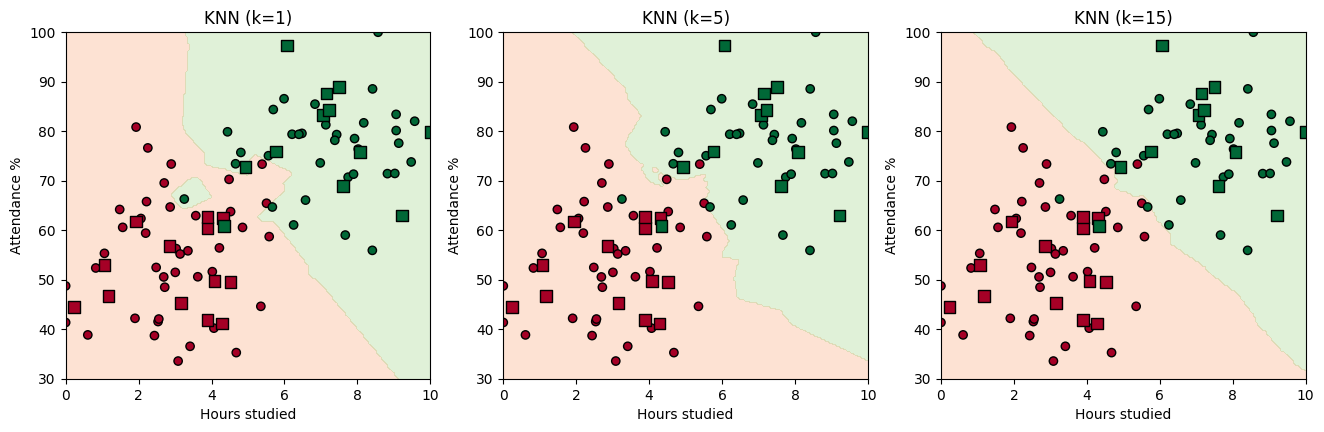

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for k, ax in zip([1, 5, 15], axes):
    knn = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=k)).fit(Xc_train, yc_train)
    plot_boundary(knn, f"KNN (k={k})", ax)
plt.show()

## Conclusion

| Technique | Type | Key idea | Watch out for |
|---|---|---|---|
| Linear | Regression | Straight line | Too simple for curved data |
| Polynomial | Regression | Adds x², x³ ... | High degree overfits |
| Ridge | Regression | L2 penalty shrinks weights | Alpha too big underfits |
| Lasso | Regression | L1 penalty, some weights become 0 | Alpha too big underfits |
| Logistic Regression | Classification | Sigmoid probability, straight boundary | Only linear boundaries |
| KNN | Classification | Vote of k nearest points | k=1 overfits, needs scaling |